## Anomaly detection model

In this notebook we are going to build the anomaly detection model to detect anomalies in volume.

This anomalies could be caused by institutional money entering or exiting the market and could be used as confluence for different trading strategies.

**Model configuration**

* Algorithm: Isolation Forest
* Contamination: 0.4% (matching vol_ratio > 3x observation)
* Features: 7 volume and CVD-based features


Importing libraries and dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load features
df = pd.read_csv('../data/BTCUSD_M5_features.csv', 
                 index_col=0, parse_dates=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (346079, 20)

Columns: ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'TICKVOL', 'VOL', 'SPREAD', 'vol_delta', 'CVD', 'CVD_50', 'CVD_100', 'vol_ma_20', 'vol_ratio', 'vol_zscore', 'return_1', 'return_12', 'candle_size', 'price_direction', 'cvd_direction', 'divergence']


### Feature definition

In this section we are going to define the features for the model.

In [3]:
# Features for anomaly detection
# Focus on volume and CVD — price features provide context
feature_cols = [
    'vol_ratio',      # volume spike detector
    'vol_zscore',     # statistical volume deviation
    'CVD_50',         # short-term buying/selling pressure
    'CVD_100',        # medium-term buying/selling pressure
    'candle_size',    # price movement magnitude
    'divergence',     # CVD vs price mismatch
    'return_12',      # 1-hour price return
]

X = df[feature_cols].copy()

print("Features selected:")
for col in feature_cols:
    print(f"  {col}")
print(f"\nShape: {X.shape}")

# Scale features — Isolation Forest benefits from scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaling complete")
print(f"Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(3)}")

Features selected:
  vol_ratio
  vol_zscore
  CVD_50
  CVD_100
  candle_size
  divergence
  return_12

Shape: (346079, 7)

Scaling complete
Mean per feature (should be ~0): [-0. -0.  0. -0.  0. -0. -0.]


### Training isolation Forest

First we are going to train an isolation forest in order to have a baseline.

In [4]:
# Isolation Forest — anomaly detection
# contamination = expected proportion of anomalies
# 0.004 ≈ 0.4% matches our vol_ratio > 3x observation

model = IsolationForest(
    n_estimators=100,
    contamination=0.004,  # ~1,350 anomalies expected
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")
model.fit(X_scaled)

# Predict anomalies
# 1 = normal, -1 = anomaly
df['anomaly'] = model.predict(X_scaled)
df['anomaly_score'] = model.score_samples(X_scaled)

# Convert to binary — 1 = anomaly, 0 = normal
df['is_anomaly'] = (df['anomaly'] == -1).astype(int)

print("Training complete")
print(f"\nAnomaly distribution:")
print(f"  Normal:   {(df['is_anomaly'] == 0).sum():,} ({(df['is_anomaly'] == 0).mean()*100:.1f}%)")
print(f"  Anomaly:  {(df['is_anomaly'] == 1).sum():,} ({(df['is_anomaly'] == 1).mean()*100:.1f}%)")

print(f"\nAnomaly score stats:")
print(df['anomaly_score'].describe().round(4))

Training Isolation Forest...
Training complete

Anomaly distribution:
  Normal:   344,694 (99.6%)
  Anomaly:  1,385 (0.4%)

Anomaly score stats:
count    346079.0000
mean         -0.4107
std           0.0592
min          -0.7999
25%          -0.4336
50%          -0.3927
75%          -0.3688
max          -0.3415
Name: anomaly_score, dtype: float64


From the results above we can see that there is a perfect consistency between the isolation forest and our previous analysis.

In the next section we are going to plot the anomalies within the price.

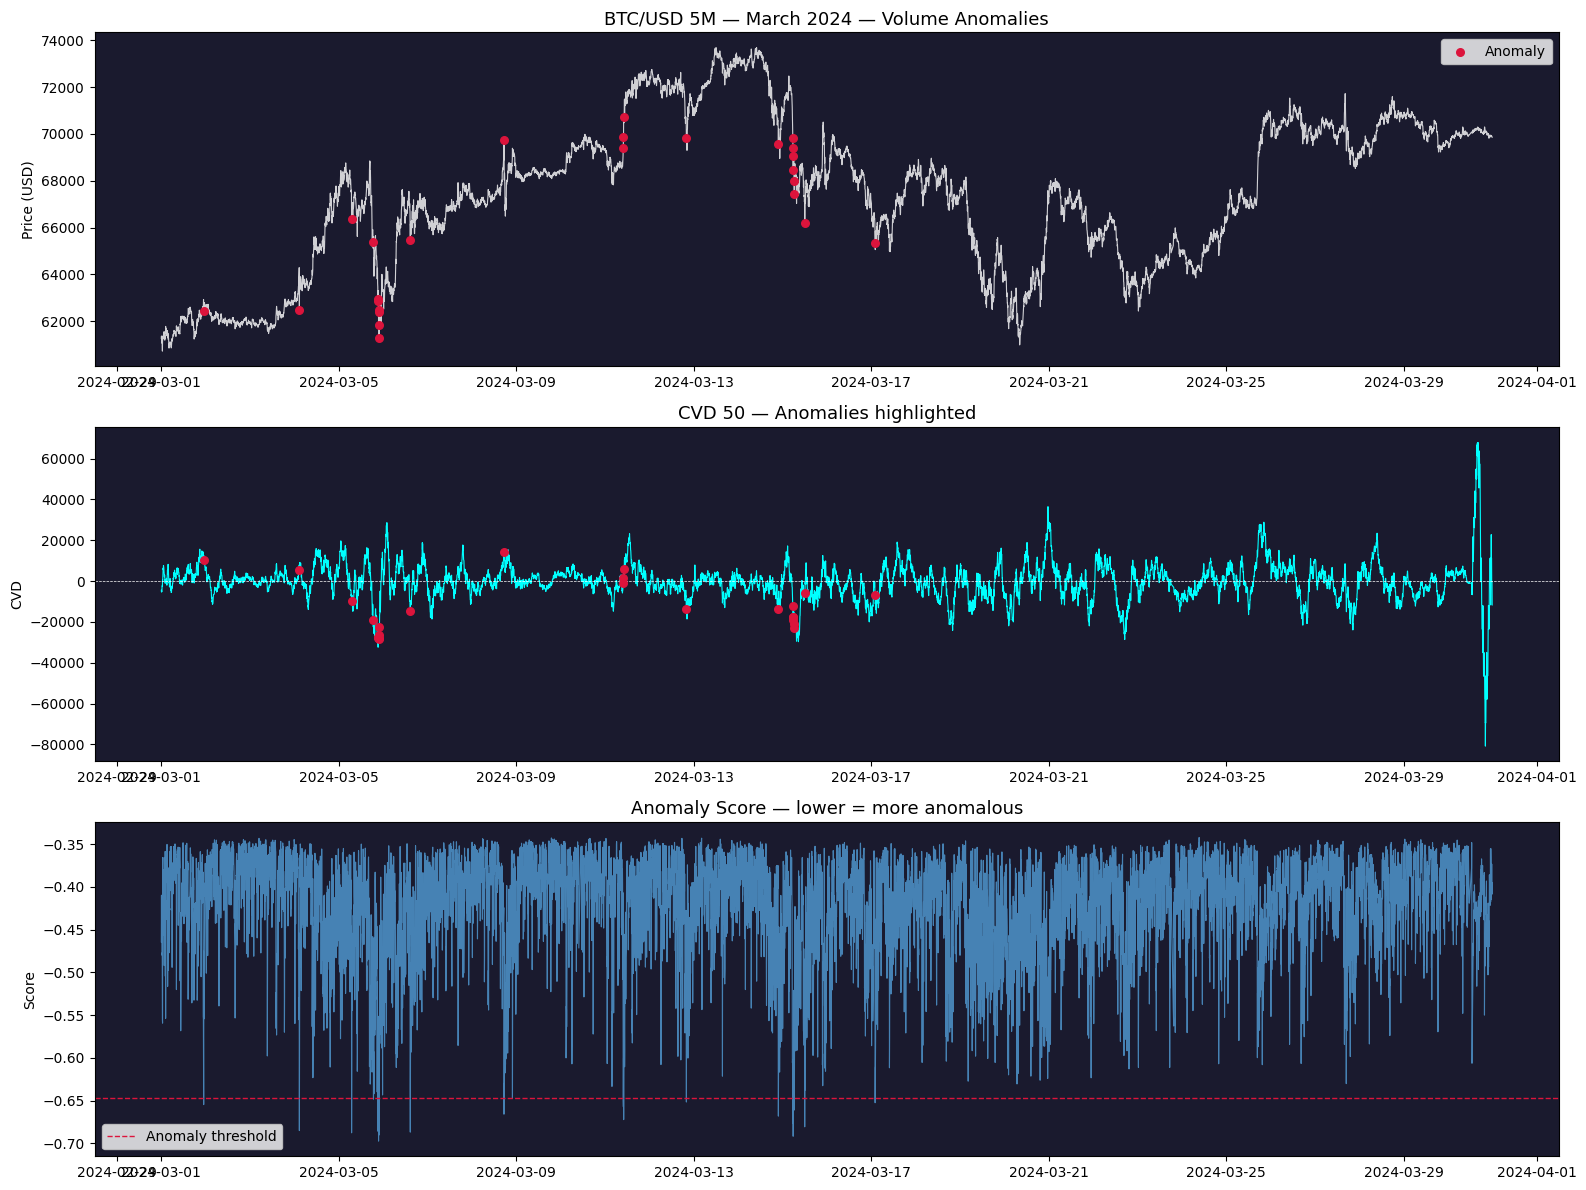

=== March 2024 Anomaly Stats ===
Total bars:    8,550
Anomalies:     25
Anomaly rate:  0.29%

Top anomalies by vol_ratio:
                        CLOSE  vol_ratio   CVD_50  divergence
datetime                                                     
2024-03-11 10:10:00  70721.34   2.849918   5816.0           0
2024-03-11 10:00:00  69884.20   2.764844   1400.0           0
2024-03-04 02:45:00  62476.97   2.437194   5187.0           1
2024-03-11 09:55:00  69388.62   2.269304  -1012.0           1
2024-03-01 23:00:00  62440.70   2.240426  10291.0           1


In [5]:
# Zoom — Marzo 2024 ATH
mask = (df.index >= '2024-03-01') & (df.index <= '2024-03-31')
df_zoom = df[mask].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# ── Price with anomalies ──────────────────────────────────────────────────────
axes[0].plot(df_zoom.index, df_zoom['CLOSE'],
             color='white', linewidth=0.8, alpha=0.8)

# Highlight anomalies on price
anomalies = df_zoom[df_zoom['is_anomaly'] == 1]
axes[0].scatter(anomalies.index, anomalies['CLOSE'],
                color='crimson', s=30, zorder=5, label='Anomaly')

axes[0].set_facecolor('#1a1a2e')
axes[0].set_title('BTC/USD 5M — March 2024 — Volume Anomalies', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# ── CVD 50 ───────────────────────────────────────────────────────────────────
axes[1].plot(df_zoom.index, df_zoom['CVD_50'],
             color='cyan', linewidth=0.8)
axes[1].scatter(anomalies.index, anomalies['CVD_50'],
                color='crimson', s=30, zorder=5)
axes[1].axhline(y=0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title('CVD 50 — Anomalies highlighted', fontsize=13)
axes[1].set_ylabel('CVD')

# ── Anomaly score ─────────────────────────────────────────────────────────────
axes[2].plot(df_zoom.index, df_zoom['anomaly_score'],
             color='steelblue', linewidth=0.8)
axes[2].axhline(y=df['anomaly_score'].quantile(0.004),
                color='crimson', linewidth=1,
                linestyle='--', label='Anomaly threshold')
axes[2].set_facecolor('#1a1a2e')
axes[2].set_title('Anomaly Score — lower = more anomalous', fontsize=13)
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/anomaly_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats for March 2024
print("=== March 2024 Anomaly Stats ===")
print(f"Total bars:    {len(df_zoom):,}")
print(f"Anomalies:     {df_zoom['is_anomaly'].sum():,}")
print(f"Anomaly rate:  {df_zoom['is_anomaly'].mean()*100:.2f}%")
print(f"\nTop anomalies by vol_ratio:")
print(df_zoom[df_zoom['is_anomaly']==1][['CLOSE','vol_ratio',
      'CVD_50','divergence']].nlargest(5, 'vol_ratio'))

### Insights

We plotted some interesting results, as we can see the anomalies that we detected are not random, they appear during high institutional activity where price has aggressive movements.

In the next section we are going to analyze the characteristics of the anomalies.

In [6]:
# Compare anomalies vs normal bars
print("=== Anomaly vs Normal — Feature Comparison ===\n")

for col in feature_cols:
    normal_mean   = df[df['is_anomaly']==0][col].mean()
    anomaly_mean  = df[df['is_anomaly']==1][col].mean()
    ratio = anomaly_mean / normal_mean if normal_mean != 0 else 0
    print(f"{col:15s}  normal={normal_mean:8.3f}  anomaly={anomaly_mean:8.3f}  ratio={ratio:.2f}x")

print(f"\n=== Top 10 anomalies by anomaly score ===")
top_anomalies = df[df['is_anomaly']==1].nsmallest(10, 'anomaly_score')
print(top_anomalies[['CLOSE', 'vol_ratio', 'vol_zscore', 
                      'CVD_50', 'candle_size', 'divergence']].to_string())

=== Anomaly vs Normal — Feature Comparison ===

vol_ratio        normal=   1.008  anomaly=   2.434  ratio=2.41x
vol_zscore       normal=  -0.045  anomaly=   2.201  ratio=-48.92x
CVD_50           normal=2816.395  anomaly=112383.845  ratio=39.90x
CVD_100          normal=5841.474  anomaly=173776.261  ratio=29.75x
candle_size      normal=   0.092  anomaly=   0.580  ratio=6.32x
divergence       normal=   0.325  anomaly=   0.326  ratio=1.00x
return_12        normal=   0.007  anomaly=  -0.084  ratio=-11.86x

=== Top 10 anomalies by anomaly score ===
                        CLOSE  vol_ratio  vol_zscore     CVD_50  candle_size  divergence
datetime                                                                                
2023-10-16 16:25:00  29360.41   9.426464    4.141986   562993.0     4.863701           0
2023-10-24 01:40:00  33979.91  12.529688    4.233018  1615602.0     5.140089           0
2023-08-29 17:20:00  26737.44   9.626710    4.178534   249416.0     2.171330           0
2023-1

**Key findings**

Anomalous bars vs normal bars:

| Feature     | Normal  | Anomaly    | Ratio  |
|-------------|---------|------------|--------|
| vol_ratio   | 1.008   | 2.434      | 2.41x  |
| vol_zscore  | -0.045  | 2.201      | extreme|
| candle_size | 0.092   | 0.580      | 6.32x  |
| CVD_50      | 2,816   | 112,383    | 39.90x |

**Interpretation**

Top anomalies show divergence=0 — price and volume moving together.
These are genuine institutional moves, not traps.
Anomalies cluster around:
- Sharp capitulations (high volume + large bearish candle)
- Breakouts with institutional backing (high volume + trend continuation)
- Distribution/accumulation zones at key price levels

Saving the model and dataset

In [7]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save model and scaler
joblib.dump(model, '../models/anomaly_model.pkl')
joblib.dump(scaler, '../models/anomaly_scaler.pkl')
joblib.dump(feature_cols, '../models/anomaly_features.pkl')

# Save dataset with anomaly labels
df.to_csv('../data/BTCUSD_5M_anomalies.csv')

print("Saved:")
print("  ../models/anomaly_model.pkl")
print("  ../models/anomaly_scaler.pkl")
print("  ../data/BTCUSD_5M_anomalies.csv")

Saved:
  ../models/anomaly_model.pkl
  ../models/anomaly_scaler.pkl
  ../data/BTCUSD_5M_anomalies.csv


### Visual validation

In this section we are going to solve the question:

Do the anomalies detected match points in time where real institutional money entered the market?

To answer this question we are going to check 3 specific periods:

* 1 October 2023 :  rally from $25K to $35K
* 2 March 2024 : ATH $73
* 3 August 2024 : strong correction

In [8]:
# Define validation periods
periods = {
    'Oct 2023 Rally':     ('2023-10-01', '2023-10-31'),
    'March 2024 ATH':     ('2024-03-01', '2024-03-31'),
    'August 2024 Crash':  ('2024-08-01', '2024-08-31'),
}

print("=== Anomaly Validation by Period ===\n")

for name, (start, end) in periods.items():
    mask = (df.index >= start) & (df.index <= end)
    df_period = df[mask]
    
    total     = len(df_period)
    anomalies = df_period['is_anomaly'].sum()
    rate      = anomalies / total * 100
    
    # Price movement
    price_change = (df_period['CLOSE'].iloc[-1] - 
                   df_period['CLOSE'].iloc[0]) / df_period['CLOSE'].iloc[0] * 100
    
    # Top anomaly
    if anomalies > 0:
        top = df_period[df_period['is_anomaly']==1].nsmallest(1, 'anomaly_score')
        top_vol  = top['vol_ratio'].values[0]
        top_date = top.index[0]
    
    print(f"--- {name} ---")
    print(f"  Price change:    {price_change:+.1f}%")
    print(f"  Total bars:      {total:,}")
    print(f"  Anomalies:       {anomalies} ({rate:.2f}%)")
    if anomalies > 0:
        print(f"  Top anomaly:     {top_date} | vol_ratio={top_vol:.2f}x")
    print()

=== Anomaly Validation by Period ===

--- Oct 2023 Rally ---
  Price change:    +27.2%
  Total bars:      8,636
  Anomalies:       359 (4.16%)
  Top anomaly:     2023-10-16 16:25:00 | vol_ratio=9.43x

--- March 2024 ATH ---
  Price change:    +14.0%
  Total bars:      8,550
  Anomalies:       25 (0.29%)
  Top anomaly:     2024-03-05 21:35:00 | vol_ratio=1.48x

--- August 2024 Crash ---
  Price change:    -8.8%
  Total bars:      8,581
  Anomalies:       35 (0.41%)
  Top anomaly:     2024-08-08 15:30:00 | vol_ratio=2.75x



Insights 

* Oct 2023  : 

BTC from 25k to 35k in weeks, explosive movements + extreme volume, massive institutional accumulation before halving (a lot of anomalies expected)

* Mar 2024 : 

Rally towards ATH, the marked was already warm, institutions were already positioned (less  anomalies detected)

* Aug 2024 : 

Small correction, sell volume but not extreme (fewer anomalies)

**October 2023**
Closer look

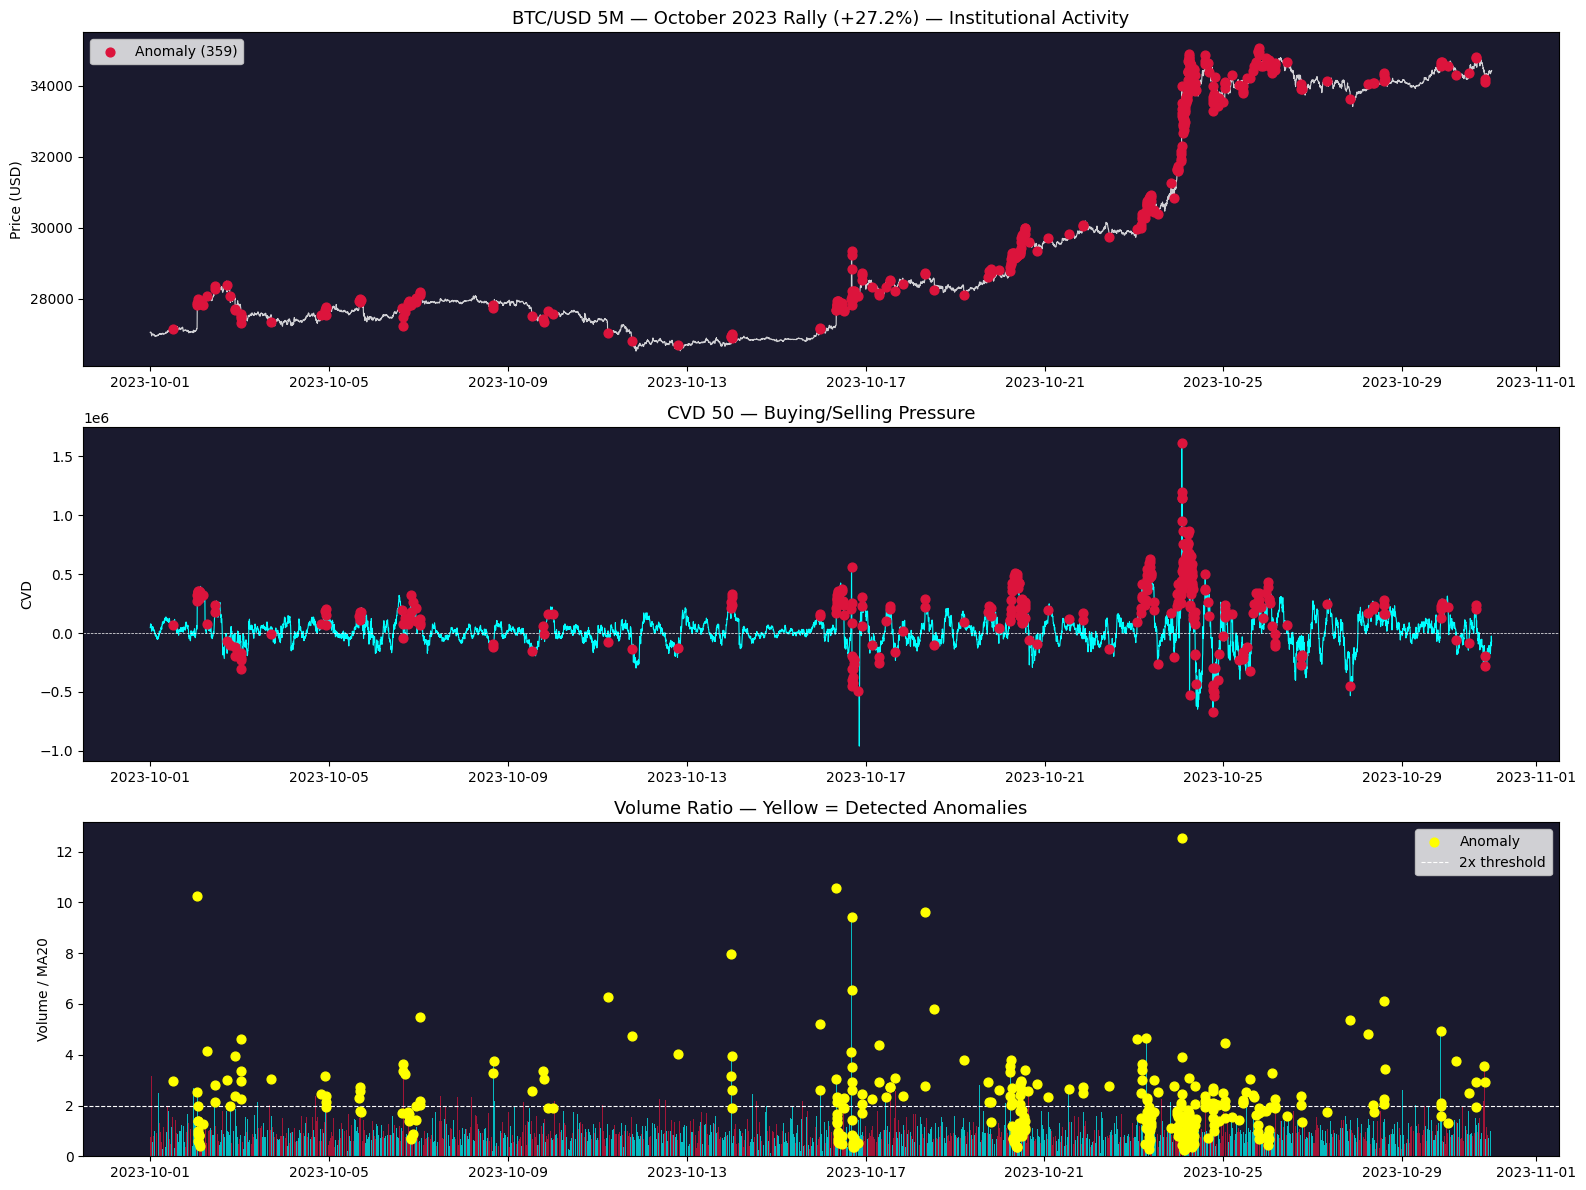

In [9]:
# Zoom — October 2023 rally
mask = (df.index >= '2023-10-01') & (df.index <= '2023-10-31')
df_zoom = df[mask].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# ── Price with anomalies ──────────────────────────────────────────────────────
axes[0].plot(df_zoom.index, df_zoom['CLOSE'],
             color='white', linewidth=0.8, alpha=0.8)

anomalies = df_zoom[df_zoom['is_anomaly'] == 1]
axes[0].scatter(anomalies.index, anomalies['CLOSE'],
                color='crimson', s=40, zorder=5, label=f'Anomaly ({len(anomalies)})')

axes[0].set_facecolor('#1a1a2e')
axes[0].set_title('BTC/USD 5M — October 2023 Rally (+27.2%) — Institutional Activity', 
                  fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# ── CVD 50 ───────────────────────────────────────────────────────────────────
axes[1].plot(df_zoom.index, df_zoom['CVD_50'],
             color='cyan', linewidth=0.8)
axes[1].scatter(anomalies.index, anomalies['CVD_50'],
                color='crimson', s=40, zorder=5)
axes[1].axhline(y=0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title('CVD 50 — Buying/Selling Pressure', fontsize=13)
axes[1].set_ylabel('CVD')

# ── Volume ratio ──────────────────────────────────────────────────────────────
axes[2].bar(df_zoom.index, df_zoom['vol_ratio'],
            color=np.where(df_zoom['vol_delta'] > 0, 'cyan', 'crimson'),
            alpha=0.7, width=0.003)
axes[2].scatter(anomalies.index, anomalies['vol_ratio'],
                color='yellow', s=40, zorder=5, label='Anomaly')
axes[2].axhline(y=2, color='white', linewidth=0.8, linestyle='--', label='2x threshold')
axes[2].set_facecolor('#1a1a2e')
axes[2].set_title('Volume Ratio — Yellow = Detected Anomalies', fontsize=13)
axes[2].set_ylabel('Volume / MA20')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/validation_oct2023.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Retrain with lower contamination
model_v2 = IsolationForest(
    n_estimators=100,
    contamination=0.001,  # 0.1% — solo eventos extremos
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_scaled)
df['anomaly_v2'] = model_v2.predict(X_scaled)
df['is_anomaly_v2'] = (df['anomaly_v2'] == -1).astype(int)

print("V2 Anomaly distribution:")
print(f"  Normal:   {(df['is_anomaly_v2']==0).sum():,}")
print(f"  Anomaly:  {(df['is_anomaly_v2']==1).sum():,} ({df['is_anomaly_v2'].mean()*100:.2f}%)")

# Check October 2023
mask = (df.index >= '2023-10-01') & (df.index <= '2023-10-31')
oct_anomalies = df[mask]['is_anomaly_v2'].sum()
print(f"\nOctober 2023 anomalies: {oct_anomalies}")

V2 Anomaly distribution:
  Normal:   345,732
  Anomaly:  347 (0.10%)

October 2023 anomalies: 141


In [11]:
# Rolling z-score — adapts to local market conditions
window = 288  # ~1 day of 5M bars

df['vol_zscore_rolling'] = (
    df['TICKVOL'] - df['TICKVOL'].rolling(window).mean()
) / df['TICKVOL'].rolling(window).std()

df['candle_zscore_rolling'] = (
    abs(df['CLOSE'] - df['OPEN']) - 
    abs(df['CLOSE'] - df['OPEN']).rolling(window).mean()
) / abs(df['CLOSE'] - df['OPEN']).rolling(window).std()

# Anomaly = both volume AND candle size are extreme locally
df['is_anomaly_v3'] = (
    (df['vol_zscore_rolling'] > 3) &      # volume 3 std above local mean
    (df['candle_zscore_rolling'] > 2)      # candle size 2 std above local mean
).astype(int)

print("V3 — Rolling Z-score distribution:")
print(f"  Normal:   {(df['is_anomaly_v3']==0).sum():,}")
print(f"  Anomaly:  {(df['is_anomaly_v3']==1).sum():,} ({df['is_anomaly_v3'].mean()*100:.3f}%)")

mask = (df.index >= '2023-10-01') & (df.index <= '2023-10-31')
oct_v3 = df[mask]['is_anomaly_v3'].sum()
print(f"\nOctober 2023 anomalies V3: {oct_v3}")

V3 — Rolling Z-score distribution:
  Normal:   343,249
  Anomaly:  2,830 (0.818%)

October 2023 anomalies V3: 110


### Cambio de enfoque

In [12]:
# Only flag anomalies that could be actionable signals
# Conditions:
# 1. Volume spike (local z-score > 3)
# 2. Large candle (local z-score > 2)  
# 3. CVD confirms direction (no divergence OR strong CVD)
# 4. Not in a cluster (isolated event)

# Anti-cluster filter — ignore if 3+ anomalies in last 10 bars
df['anomaly_cluster'] = df['is_anomaly_v3'].rolling(10).sum()

df['is_anomaly_final'] = (
    (df['is_anomaly_v3'] == 1) &
    (df['anomaly_cluster'] <= 2) &      # isolated event
    (df['vol_ratio'] > 2.0)             # clear volume spike
).astype(int)

print("Final anomaly distribution:")
print(f"  Normal:   {(df['is_anomaly_final']==0).sum():,}")
print(f"  Anomaly:  {(df['is_anomaly_final']==1).sum():,} ({df['is_anomaly_final'].mean()*100:.3f}%)")

mask = (df.index >= '2023-10-01') & (df.index <= '2023-10-31')
oct_final = df[mask]['is_anomaly_final'].sum()
total_oct  = mask.sum()
print(f"\nOctober 2023: {oct_final} anomalies ({oct_final/total_oct*100:.2f}%)")

mask_mar = (df.index >= '2024-03-01') & (df.index <= '2024-03-31')
mar_final = df[mask_mar]['is_anomaly_final'].sum()
print(f"March 2024:   {mar_final} anomalies ({mar_final/mask_mar.sum()*100:.2f}%)")

mask_aug = (df.index >= '2024-08-01') & (df.index <= '2024-08-31')
aug_final = df[mask_aug]['is_anomaly_final'].sum()
print(f"August 2024:  {aug_final} anomalies ({aug_final/mask_aug.sum()*100:.2f}%)")

Final anomaly distribution:
  Normal:   344,895
  Anomaly:  1,184 (0.342%)

October 2023: 78 anomalies (0.90%)
March 2024:   11 anomalies (0.13%)
August 2024:  11 anomalies (0.13%)


### Visual

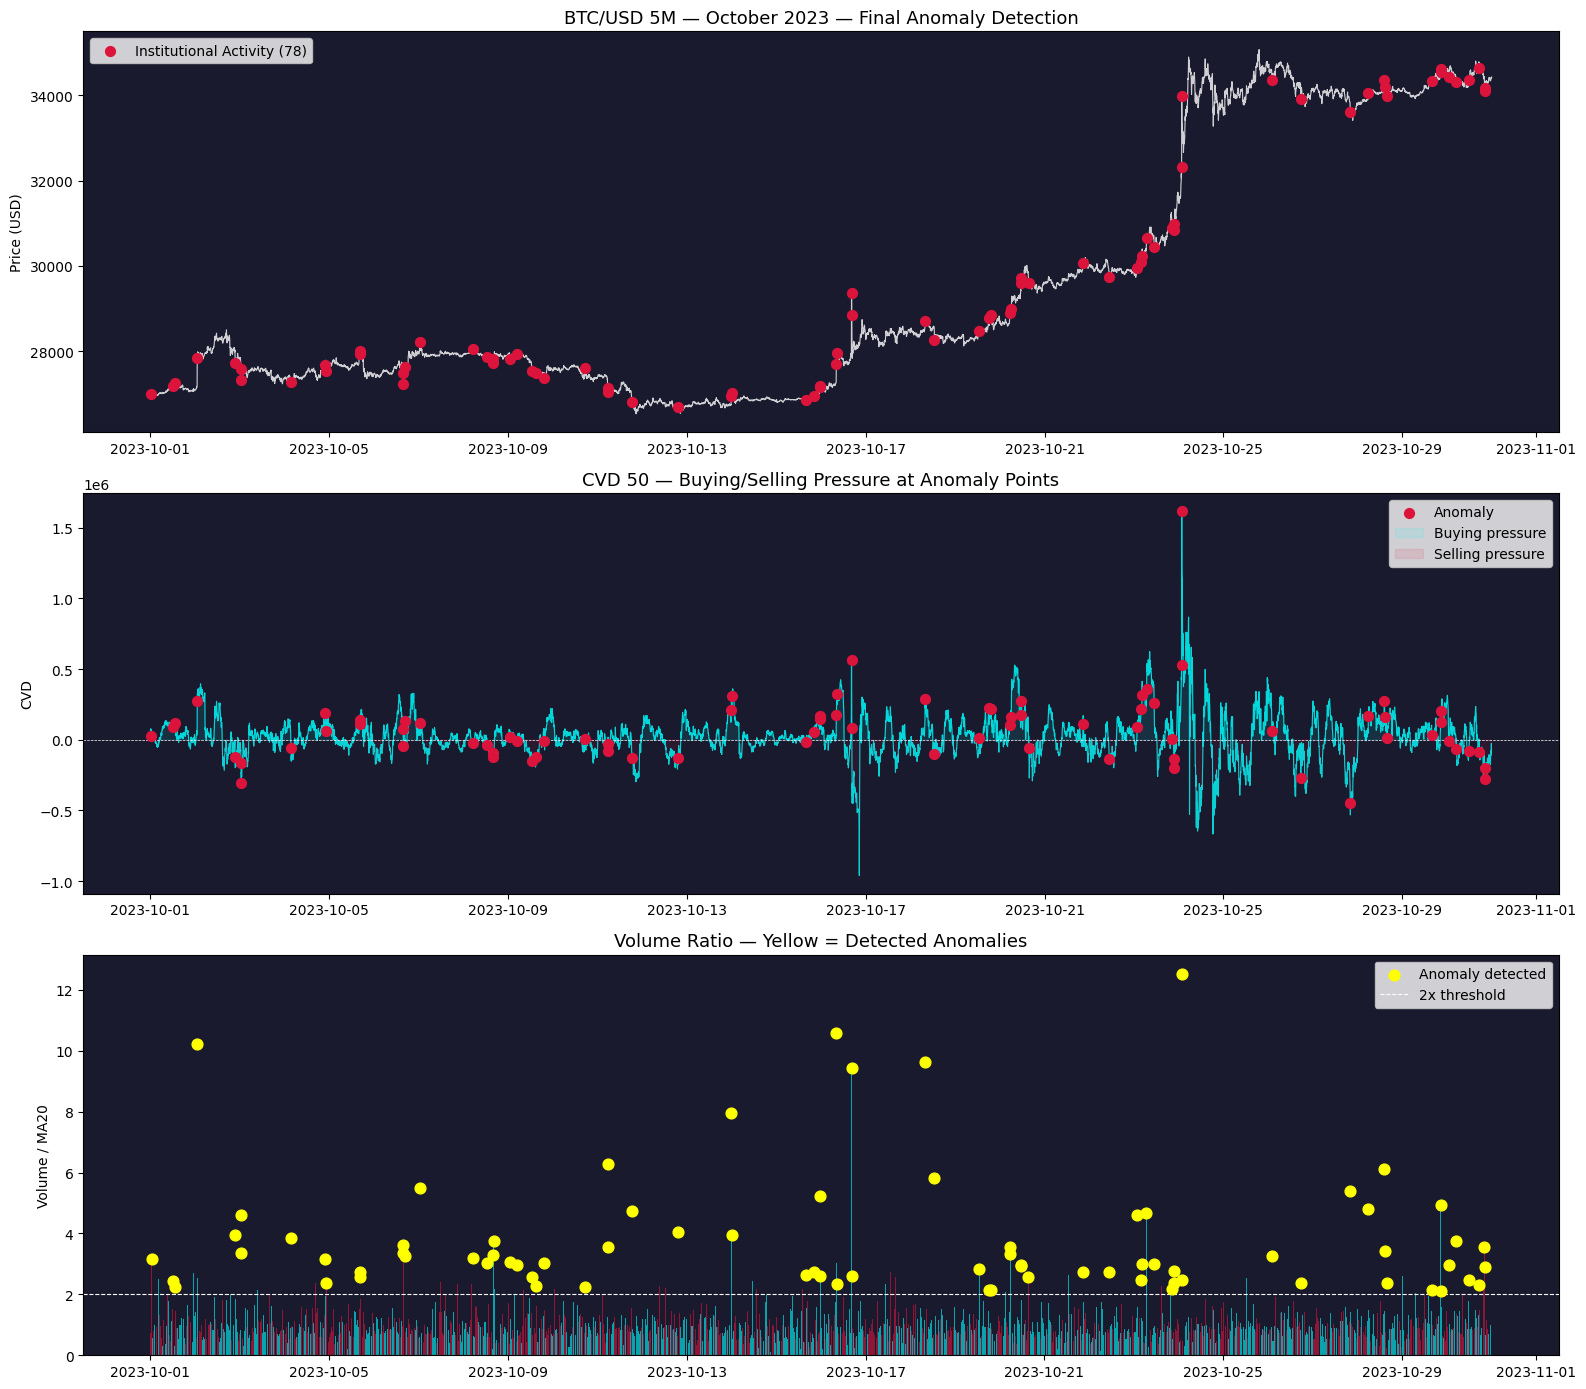

In [14]:
# Final visualization — October 2023 with CVD
mask = (df.index >= '2023-10-01') & (df.index <= '2023-10-31')
df_zoom = df[mask].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

anomalies = df_zoom[df_zoom['is_anomaly_final'] == 1]

# ── Price with anomalies ──────────────────────────────────────────────────────
axes[0].plot(df_zoom.index, df_zoom['CLOSE'],
             color='white', linewidth=0.8, alpha=0.8)
axes[0].scatter(anomalies.index, anomalies['CLOSE'],
                color='crimson', s=50, zorder=5,
                label=f'Institutional Activity ({len(anomalies)})')
axes[0].set_facecolor('#1a1a2e')
axes[0].set_title('BTC/USD 5M — October 2023 — Final Anomaly Detection', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# ── CVD 50 with anomalies ─────────────────────────────────────────────────────
axes[1].plot(df_zoom.index, df_zoom['CVD_50'],
             color='cyan', linewidth=0.8, alpha=0.8)
axes[1].scatter(anomalies.index, anomalies['CVD_50'],
                color='crimson', s=50, zorder=5, label='Anomaly')
axes[1].axhline(y=0, color='white', linewidth=0.5, linestyle='--')
axes[1].fill_between(df_zoom.index, df_zoom['CVD_50'], 0,
                     where=df_zoom['CVD_50'] > 0,
                     color='cyan', alpha=0.1, label='Buying pressure')
axes[1].fill_between(df_zoom.index, df_zoom['CVD_50'], 0,
                     where=df_zoom['CVD_50'] < 0,
                     color='crimson', alpha=0.1, label='Selling pressure')
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title('CVD 50 — Buying/Selling Pressure at Anomaly Points', fontsize=13)
axes[1].set_ylabel('CVD')
axes[1].legend()

# ── Volume ratio with anomalies ───────────────────────────────────────────────
axes[2].bar(df_zoom.index, df_zoom['vol_ratio'],
            color=np.where(df_zoom['vol_delta'] > 0, 'cyan', 'crimson'),
            alpha=0.6, width=0.003)
axes[2].scatter(anomalies.index, anomalies['vol_ratio'],
                color='yellow', s=60, zorder=5, label='Anomaly detected')
axes[2].axhline(y=2, color='white', linewidth=0.8,
                linestyle='--', label='2x threshold')
axes[2].set_facecolor('#1a1a2e')
axes[2].set_title('Volume Ratio — Yellow = Detected Anomalies', fontsize=13)
axes[2].set_ylabel('Volume / MA20')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/validation_final_oct2023.png', dpi=150, bbox_inches='tight')
plt.show()